# Data Generation

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from numpy import pi, cos, sin, random
from scipy.stats import ortho_group

## 12-Dimensional Data

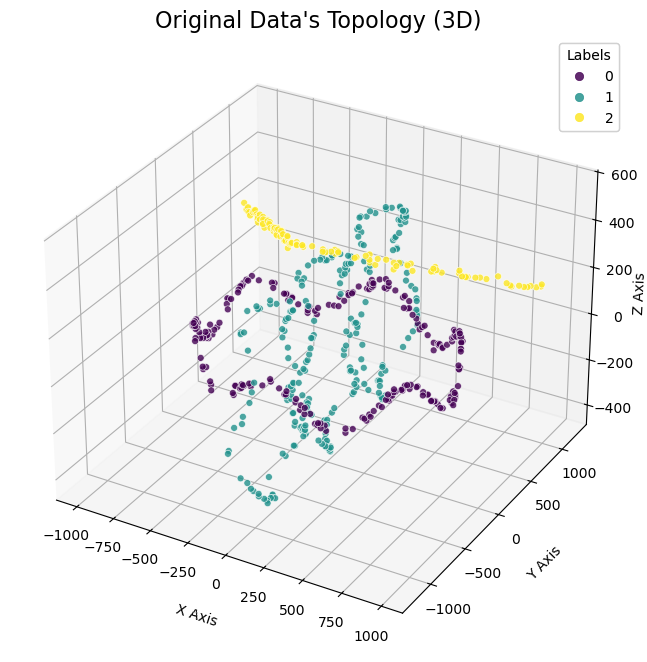

In [2]:
os.makedirs("DATA", exist_ok=True)
os.makedirs("images", exist_ok=True)
np.random.seed(123)

N, L, LL = 600, 3, 12
OM, OMM = ortho_group.rvs(dim=L), ortho_group.rvs(dim=LL)
p0, p1, R0, R1, NOISE = 35, 45, 800, 400, 5

x, y, r = np.zeros((N,L)), np.zeros(N), np.random.randint(0,100,N)
noise = np.random.randn(N,L)*10
xx, nnoise = np.zeros((N,LL)), np.random.randn(N,LL)*10
X, XX_raw = np.zeros_like(x), np.zeros_like(xx)

# data generation
for n in range(N):
    if r[n] < p0:
        y[n] = 0
        q = random.rand() * 2 * pi
        x[n,:3] = (R0*cos(q), R0*sin(q), -(R0/10)*cos(6*q))
    elif r[n] < p1 + p0:
        y[n] = 1
        q = random.rand() * 2 * pi
        x[n,:3] = (-(R1/5)*sin(4*q), R1*cos(q), R1*sin(q))
        x[n,:3] = x[n,:3] + R0 * np.array((0, random.randint(3) - 1, 0))
    else:
        y[n] = 2
        q = random.rand() * 1000.
        x[n,:3] = ((random.randint(2)-0.5)*2*q, 1.333*q-R1, 1.333*R1-0.333*q)
        
    x[n] = x[n] + noise[n]
    xx[n,:3] = x[n]
    nnoise[n,3:] = nnoise[n,3:] * NOISE
    xx[n] = xx[n] + nnoise[n]
    X[n] = np.dot(OM, x[n])
    XX_raw[n] = np.dot(OMM, xx[n])
    
y = y.astype(int)

np.savetxt("DATA/X_12d_topology.dat", XX_raw, delimiter='\t')
np.savetxt("DATA/y_12d_topology.dat", y, fmt="%d")

# plot and save
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=y, cmap='viridis', s=25, alpha=0.8, edgecolors='w', linewidth=0.5)

ax.set_title("Original Data's Topology (3D)", fontsize=16)
ax.set_xlabel('X Axis', labelpad=10)
ax.set_ylabel('Y Axis', labelpad=10)
ax.set_zlabel('Z Axis',labelpad=0.5)

legend1 = ax.legend(*scatter.legend_elements(), title="Labels", loc="upper right")
ax.add_artist(legend1)

filepath = "images/03_topology_12d_clean.png"
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

## Point of Failure

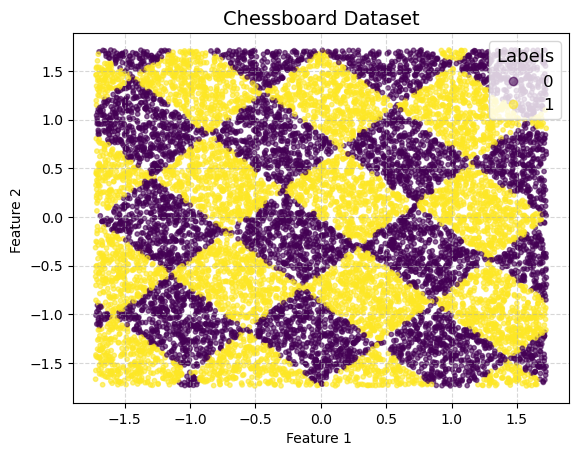

In [3]:
from useful import NF 

#mkdir if not exists
os.makedirs("DATA", exist_ok=True)
os.makedirs("images", exist_ok=True)
np.random.seed(12345)

# Parameters
N = 12000
L = 2    
B = 10

TYPE_COMPLEX = 4
X_complex_raw = (np.random.random((N, L))) * B
y_complex = np.zeros(N)

for i in range(N):
    y_complex[i] = NF(X_complex_raw[i], B, TYPE_COMPLEX)

scaler_complex = StandardScaler()
X_complex_scaled = scaler_complex.fit_transform(X_complex_raw)

# saving dataset
np.savetxt("DATA/X_type4_complex.dat", X_complex_scaled)
np.savetxt("DATA/y_type4_complex.dat", y_complex, fmt="%d")

#Plot and save
fig= plt.plot(figsize=(14, 10))
scatter1 = plt.scatter(X_complex_scaled[:, 0], X_complex_scaled[:, 1], 
                       c=y_complex, cmap='viridis', alpha=0.6, s=10)
plt.title("Chessboard Dataset", fontsize=14)
plt.xlabel("Feature 1 ")
plt.ylabel("Feature 2 ")
plt.grid(True, linestyle='--', alpha=0.5)

#Creates legend with labels
handles, _ = scatter1.legend_elements()
plt.legend(handles, ["0", "1"], title="Labels", loc="upper right", fontsize=12, title_fontsize=13)

# Salviamo la figura nella cartella 'images' ad alta risoluzione (300 DPI)
filepath_plot = "images/pattern_seeking_datasets_comparison.png"
plt.savefig(filepath_plot, dpi=300, bbox_inches='tight')

# Mostriamo il grafico a schermo
plt.show()